In [1]:
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Первичный анализ данных

In [3]:
# загрузка данных
df = pd.read_csv("antibody_sequences.csv")

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())

# инфо
print("\nИнфо:")
print(df.info())

# проверка на дубликаты
print("\nКоличество полных дубликатов:", df.duplicated().sum())
print("\nКоличество дубликатов в id:",  df.id.duplicated().sum())
print("\nКоличество дубликатов в cdr3_sequence:", df.cdr3_sequence.duplicated().sum())
print("\nКоличество дубликатов в binding_score:", df.binding_score.duplicated().sum())


Размер датасета: (400, 3)

Первые строки:
   id      cdr3_sequence  binding_score
0  A1     LWMLLYWVNMKDSM          0.735
1  A2  MVYGVNIANEFFMHIKP          0.666
2  A3    NHADYINCVIETCGS          0.401
3  A4   CKIIIRPYLCKFYTSR          0.507
4  A5    IELYRELQYFWSKKM          0.656

Инфо:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             400 non-null    object 
 1   cdr3_sequence  400 non-null    object 
 2   binding_score  400 non-null    float64
dtypes: float64(1), object(2)
memory usage: 9.5+ KB
None

Количество полных дубликатов: 0

Количество дубликатов в id: 0

Количество дубликатов в cdr3_sequence: 0

Количество дубликатов в binding_score: 119


In [5]:
# длина CDR3
df["cdr3_length"] = df["cdr3_sequence"].str.len()
print("\n")
print(df.head())

print("\nСтатистика длины CDR3:")
print(df["cdr3_length"].describe())



   id      cdr3_sequence  binding_score  cdr3_length
0  A1     LWMLLYWVNMKDSM          0.735           14
1  A2  MVYGVNIANEFFMHIKP          0.666           17
2  A3    NHADYINCVIETCGS          0.401           15
3  A4   CKIIIRPYLCKFYTSR          0.507           16
4  A5    IELYRELQYFWSKKM          0.656           15

Статистика длины CDR3:
count    400.000000
mean      14.015000
std        2.543807
min       10.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       18.000000
Name: cdr3_length, dtype: float64


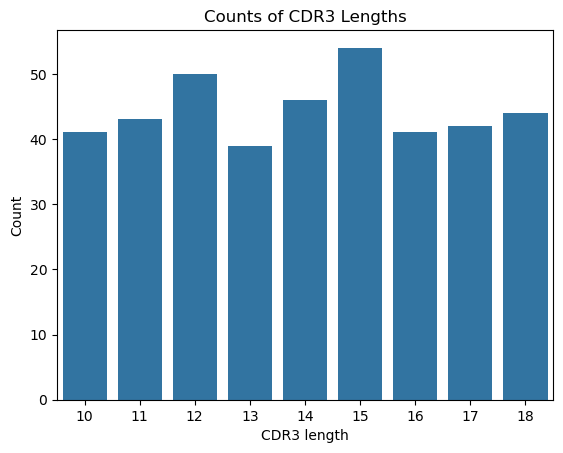

In [7]:
# график распределения длин CDR3

sns.countplot(x=df["cdr3_length"])

plt.xlabel("CDR3 length")
plt.ylabel("Count")
plt.title("Counts of CDR3 Lengths")

plt.show()

In [9]:
# частоты аминокислот
all_sequences = "".join(df["cdr3_sequence"].dropna())
aa_counts = Counter(all_sequences)

aa_freq = pd.DataFrame.from_dict(
    aa_counts, orient="index", columns=["count"]
).sort_values("count", ascending=False)

aa_freq["frequency"] = aa_freq["count"] / aa_freq["count"].sum()

print("\nЧастоты аминокислот:")
print(aa_freq)


Частоты аминокислот:
   count  frequency
Y    302   0.053871
H    299   0.053336
S    298   0.053157
C    298   0.053157
K    294   0.052444
M    293   0.052265
F    287   0.051195
N    284   0.050660
W    282   0.050303
V    280   0.049946
E    280   0.049946
T    279   0.049768
I    278   0.049590
A    275   0.049055
Q    271   0.048341
P    267   0.047628
R    267   0.047628
L    264   0.047092
G    255   0.045487
D    253   0.045130


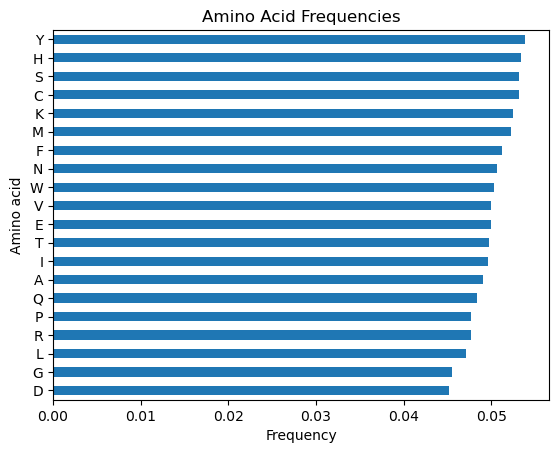

In [11]:
# график частот аминокислот
aa_freq["frequency"].sort_values().plot(kind="barh")

plt.xlabel("Frequency")
plt.ylabel("Amino acid")
plt.title("Amino Acid Frequencies")

plt.show()

## 2. Feature engineering

In [13]:
# группы аминокислот
hydrophobic = set("AILMFWVY")
aromatic = set("FWY")
charged = set("DEKRH")
positive = "KR"
negative = "DE"

# доля гидрофобных аминокислот
df["hydrophobic_fraction"] = df["cdr3_sequence"].apply(
    lambda seq: sum(aa in hydrophobic for aa in seq) / len(seq)
)

# доля ароматических аминокислот
df["aromatic_fraction"] = df["cdr3_sequence"].apply(
    lambda seq: sum(aa in aromatic for aa in seq) / len(seq)
)

# доля заряженных аминокислот
df["charged_fraction"] = df["cdr3_sequence"].apply(
    lambda seq: sum(aa in charged for aa in seq) / len(seq)
)

# заряд при pH 7
df["net_charge"] = df["cdr3_sequence"].apply(
    lambda seq: (sum(aa in positive for aa in seq) - sum(aa in negative for aa in seq)) / len(seq)
)

# доля glycine (гибкость)
df["glycine_fraction"] = df["cdr3_sequence"].apply(
    lambda x: x.count("G") / len(x)
)

# доля proline (жёсткость)
df["proline_fraction"] = df["cdr3_sequence"].apply(
    lambda x: x.count("P") / len(x)
)

In [15]:
df.head()

,id,cdr3_sequence,binding_score,cdr3_length,hydrophobic_fraction,aromatic_fraction,charged_fraction,net_charge,glycine_fraction,proline_fraction
0,A1,LWMLLYWVNMKDSM,0.735,14,0.714286,0.214286,0.142857,0.000000,0.000000,0.000000
1,A2,MVYGVNIANEFFMHIKP,0.666,17,0.588235,0.176471,0.176471,0.000000,0.058824,0.058824
2,A3,NHADYINCVIETCGS,0.401,15,0.333333,0.066667,0.200000,-0.133333,0.066667,0.000000
3,A4,CKIIIRPYLCKFYTSR,0.507,16,0.437500,0.187500,0.250000,0.250000,0.000000,0.062500
4,A5,IELYRELQYFWSKKM,0.656,15,0.533333,0.266667,0.333333,0.066667,0.000000,0.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    400 non-null    object 
 1   cdr3_sequence         400 non-null    object 
 2   binding_score         400 non-null    float64
 3   cdr3_length           400 non-null    int64  
 4   hydrophobic_fraction  400 non-null    float64
 5   aromatic_fraction     400 non-null    float64
 6   charged_fraction      400 non-null    float64
 7   net_charge            400 non-null    float64
 8   glycine_fraction      400 non-null    float64
 9   proline_fraction      400 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 31.4+ KB


In [19]:
# список признаков
features = [
    "cdr3_length",
    "hydrophobic_fraction",
    "aromatic_fraction",
    "charged_fraction",
    "net_charge",
    "glycine_fraction",
    "proline_fraction"
]

## 3. Статистический анализ

In [21]:
high_binders = df[df["binding_score"] > 0.7]
low_binders = df[df["binding_score"] < 0.3]

print("High binders:", len(high_binders))
print("Low binders:", len(low_binders))

High binders: 26
Low binders: 44


<Axes: xlabel='cdr3_length', ylabel='Count'>

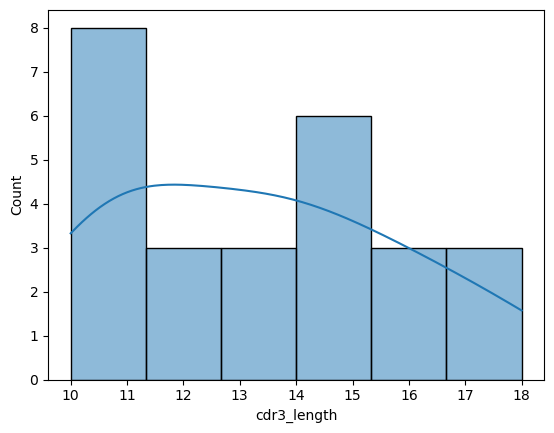

In [23]:
# график распределения одного из признаков
sns.histplot(high_binders["cdr3_length"], kde=True)

Для сравнения распределений фич между high и low binders больше подходит непараметрический тест Mann–Whitney, так как:
 - группы независимые и их размеры относительно небольшие
 - фичи (например, доли аминокислот) ограничены диапазоном значений и могут иметь ненормальное распределение

In [26]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [28]:
# тест Мана-Уитни с поправкой на множественное сравнение (метод Бенджамини-Хохберга)

results = []

for feature in features:

    high_values = high_binders[feature].dropna()
    low_values = low_binders[feature].dropna()

    stat, p_value = mannwhitneyu(
        high_values,
        low_values,
        alternative="two-sided"
    )
    
    results.append({
        "feature": feature,
        "high_median": high_values.median(),
        "low_median": low_values.median(),
        "p_value": p_value
    })

results_df = pd.DataFrame(results).sort_values("p_value")

# поправка на множественное сравнение
results_df["p_adjusted"] = multipletests(results_df["p_value"], method="fdr_bh")[1]

results_df["significant"] = results_df["p_adjusted"] < 0.05

print(results_df)

                feature  high_median  low_median       p_value    p_adjusted  \
1  hydrophobic_fraction     0.620192    0.218254  3.633858e-12  2.543700e-11   
2     aromatic_fraction     0.300000    0.064583  2.171719e-11  7.601015e-11   
3      charged_fraction     0.129167    0.358289  9.459957e-09  2.207323e-08   
6      proline_fraction     0.000000    0.066667  1.982194e-04  3.468839e-04   
5      glycine_fraction     0.000000    0.000000  1.496683e-02  2.095356e-02   
0           cdr3_length    13.000000   14.000000  5.604095e-01  6.538110e-01   
4            net_charge     0.000000    0.000000  6.784182e-01  6.784182e-01   

   significant  
1         True  
2         True  
3         True  
6         True  
5         True  
0        False  
4        False  


## 4. Визуализация

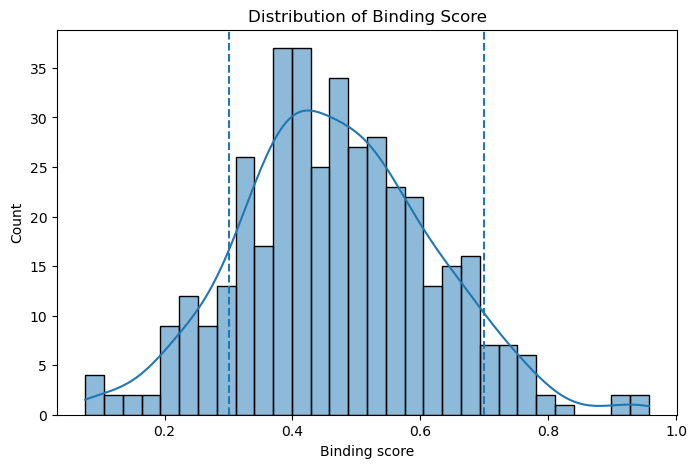

In [31]:
# распределение binding_score
plt.figure(figsize=(8,5))

sns.histplot(
    df["binding_score"],
    bins = 30,
    kde=True
)

plt.axvline(0.7, linestyle="--")
plt.axvline(0.3, linestyle="--")

plt.title("Distribution of Binding Score")
plt.xlabel("Binding score")

plt.show()

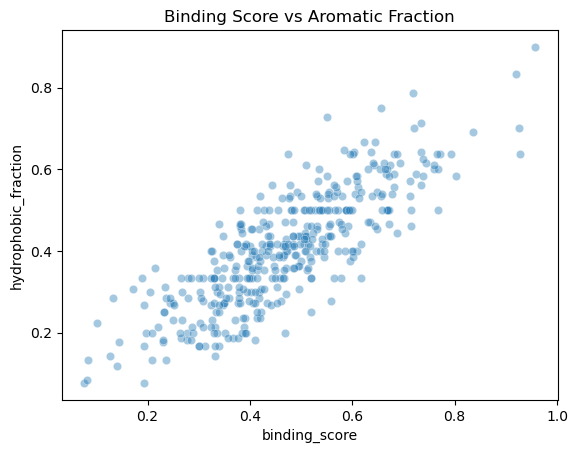

In [33]:
# scatter plot одного признака против binding_score

sns.scatterplot(
    x="binding_score",
    y="hydrophobic_fraction",
    data=df,
    alpha=0.4
)

plt.title("Binding Score vs Aromatic Fraction")
plt.show()

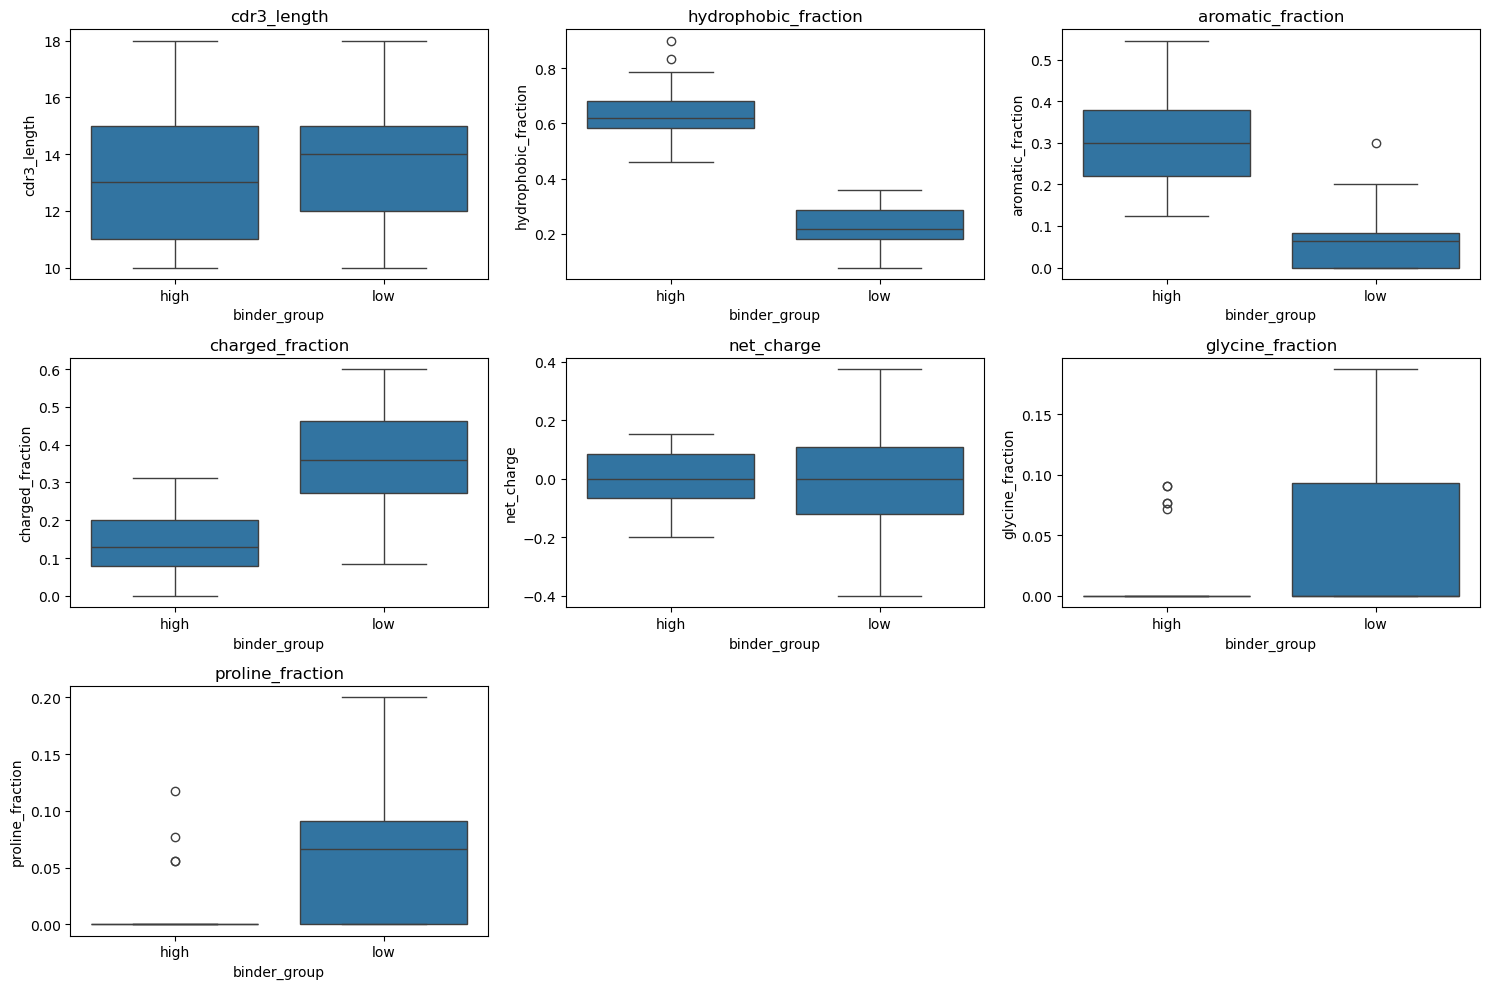

In [35]:
# бокс-плоты признаков для high/low binders

# Добавляем колонку с группой
df["binder_group"] = "medium"
df.loc[df["binding_score"] > 0.7, "binder_group"] = "high"
df.loc[df["binding_score"] < 0.3, "binder_group"] = "low"


plot_df = df[df["binder_group"].isin(["high", "low"])]
long_df = plot_df.melt(
    id_vars="binder_group",
    value_vars=features,
    var_name="feature",
    value_name="value"
)

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        data=plot_df,
        x="binder_group",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

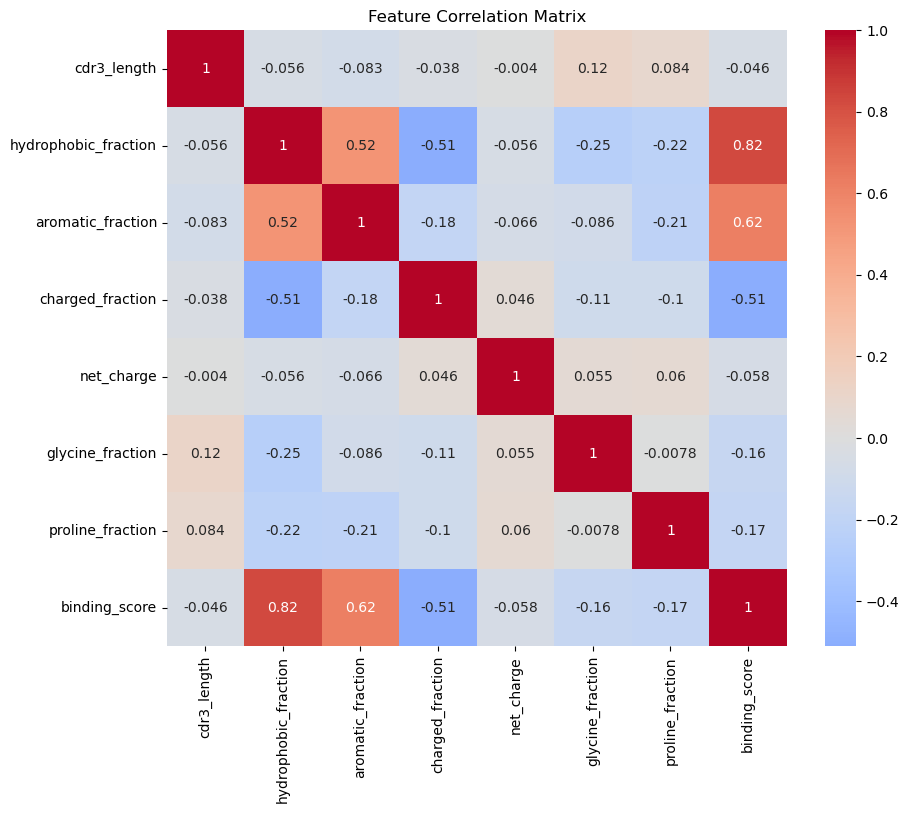

In [37]:
# корелляция признаков
corr = df[features + ["binding_score"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Feature Correlation Matrix")
plt.show()

## 5. Мини-модель 

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report

In [41]:
# подготовка данных

# берем только high/low binders
df_model = df[df["binder_group"].isin(["high", "low"])].copy()

# матрица признаков
X = df_model[features]

# кодируем в целевую переменную 
y = LabelEncoder().fit_transform(df_model["binder_group"])  # high=1, low=0

# разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### LogisticRegression

In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]  # вероятность принадлежности к high
y_pred_lr = (y_pred_proba_lr > 0.5).astype(int)  


In [47]:
# метрики качества lr
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("ROC AUC:", auc_lr)
print("Accuracy:", acc_lr)
print("Confusion Matrix:\n", cm_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


ROC AUC: 1.0
Accuracy: 0.8571428571428571
Confusion Matrix:
 [[ 5  3]
 [ 0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.81      1.00      0.90        13

    accuracy                           0.86        21
   macro avg       0.91      0.81      0.83        21
weighted avg       0.88      0.86      0.85        21



In [49]:
# фичи lr
lr_coefs = pd.Series(lr.coef_[0], index=features).sort_values(ascending=False)
lr_coefs

charged_fraction        1.192144
proline_fraction        0.330338
glycine_fraction        0.266903
cdr3_length             0.066202
net_charge             -0.129276
aromatic_fraction      -1.613284
hydrophobic_fraction   -2.570813
dtype: float64

### Random forest 

In [53]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_proba_rf > 0.5).astype(int)  

In [55]:
# метрики качества rf
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("ROC AUC:", auc_rf)
print("Accuracy:", acc_rf)
print("Confusion Matrix:\n", cm_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

ROC AUC: 1.0
Accuracy: 1.0
Confusion Matrix:
 [[ 8  0]
 [ 0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        13

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [57]:
# фичи rf
rf_feature_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
rf_feature_importances

hydrophobic_fraction    0.442613
aromatic_fraction       0.291246
charged_fraction        0.132199
proline_fraction        0.057033
cdr3_length             0.026072
glycine_fraction        0.026033
net_charge              0.024804
dtype: float64

Смысл метрик:
- accuracy — процент правильных ответов, но без учёта того, какие ошибки важнее
- ROC AUC – общая способность различать high/low binders независимо от порога
- Recall (полнота) – доля найденных положительных объектов среди реальных положительных; смотрим если важно не упустить реальные high binders
- Precision (точность) – доля правильных среди всех положительных предсказаний; смотрим если важно не тратить ресурсы на ложные high binders
- F1-score – баланс precision и recall (важно, если high binders редки)

Оценка моделей по метрикам качества: 
- Random Forest полностью разделил классы high и low binders (accuracy и ROC AUC равны 1)
- Logistic Regression корректно выявляет большинство high binders, хотя допускает некоторые ложноположительные предсказания для low binders

Общие выводы по признакам:

- Наиболее важные признаки для связывания — доля гидрофобных, ароматических и заряженных аминокислот.
- Статистический тест Мана-Уитни подтверждает, что эти признаки статзначимо различаются между high и low binders. Пролин и глицин тоже влияют, но слабее. Длина CDR3 и заряд — не значимы.
- Logistic Regression указывает, что больше заряженных аминокислот, пролина и глицина повышает вероятность high binder, а гидрофобные и ароматические аминокислоты имеют отрицательный эффект. Но эта модель учитывает только линейные эффекты и чувствительна к мультиколлинеарности.
- Random Forest подтверждает важность признаков hydrophobic_fraction и aromatic_fraction. Эта модель учитывает комбинации и нелинейные взаимодействия между признаками.

Ограничения анализа: 

- малый размер выборки (26 high, 44 low) делает результаты чувствительными к случайным особенностям данных и может привести к переобучению модели
- упрощение binding_score до high/low может скрывать тонкие эффекты отдельных принаков